In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor


df = pd.read_csv(
    "online_shoppers_intention.csv"
)

int_faktoriai = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

df[int_faktoriai] = df[int_faktoriai].astype("category")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [118]:
missing_table = pd.DataFrame(
    {"Praleista": df.isna().sum()}
)

missing_table

,Praleista
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [119]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


# Pradinė analizė/Išskirtys

In [120]:
df = df[
    ~(df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"] == 0) &
    ~((df["Administrative_Duration"] != 0) & (df["Administrative"] == 0)) &
    ~((df["Informational_Duration"] != 0) & (df["Administrative"] == 0)) &
    ~((df["ProductRelated_Duration"] != 0) & (df["ProductRelated"] == 0))
]

In [121]:
weekend_freq = (
    df
    .groupby("Revenue")
    .agg(Dažnis=("Revenue", "count"))
    .assign(**{"Santykinis dažnis": lambda x: (x["Dažnis"] / x["Dažnis"].sum() * 100).round(2)})
    .reset_index()
)

weekend_freq

,Revenue,Dažnis,Santykinis dažnis
0,False,9389,83.72
1,True,1826,16.28


In [122]:
def make_cross_table(data, column):
    result = (
        data
        .groupby([column, "Revenue"])
        .agg(Dažnis=(column, "count"))
        .reset_index()
        .pivot_table(index=column, columns="Revenue", values="Dažnis", fill_value=0)
        .reset_index()
    )
    result.columns.name = None
    result.columns = [str(c) for c in result.columns]
    result["Bendrai"] = result["False"] + result["True"]

make_cross_table(df, "OperatingSystems")
make_cross_table(df, "Browser")
make_cross_table(df, "TrafficType")


In [123]:
df = (
    df
    [~df["OperatingSystems"].isin([5, 6, 7])]
    [~df["Browser"].isin([3, 9, 11, 12])]
    [df["Month"] != "Feb"]
    [df["VisitorType"] != "Other"]
    .drop(columns=["TrafficType"])
)

/var/folders/1j/plyr0c_d22j_61hmyf52pckw0000gq/T/ipykernel_34471/181095689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df
/var/folders/1j/plyr0c_d22j_61hmyf52pckw0000gq/T/ipykernel_34471/181095689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df
/var/folders/1j/plyr0c_d22j_61hmyf52pckw0000gq/T/ipykernel_34471/181095689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df


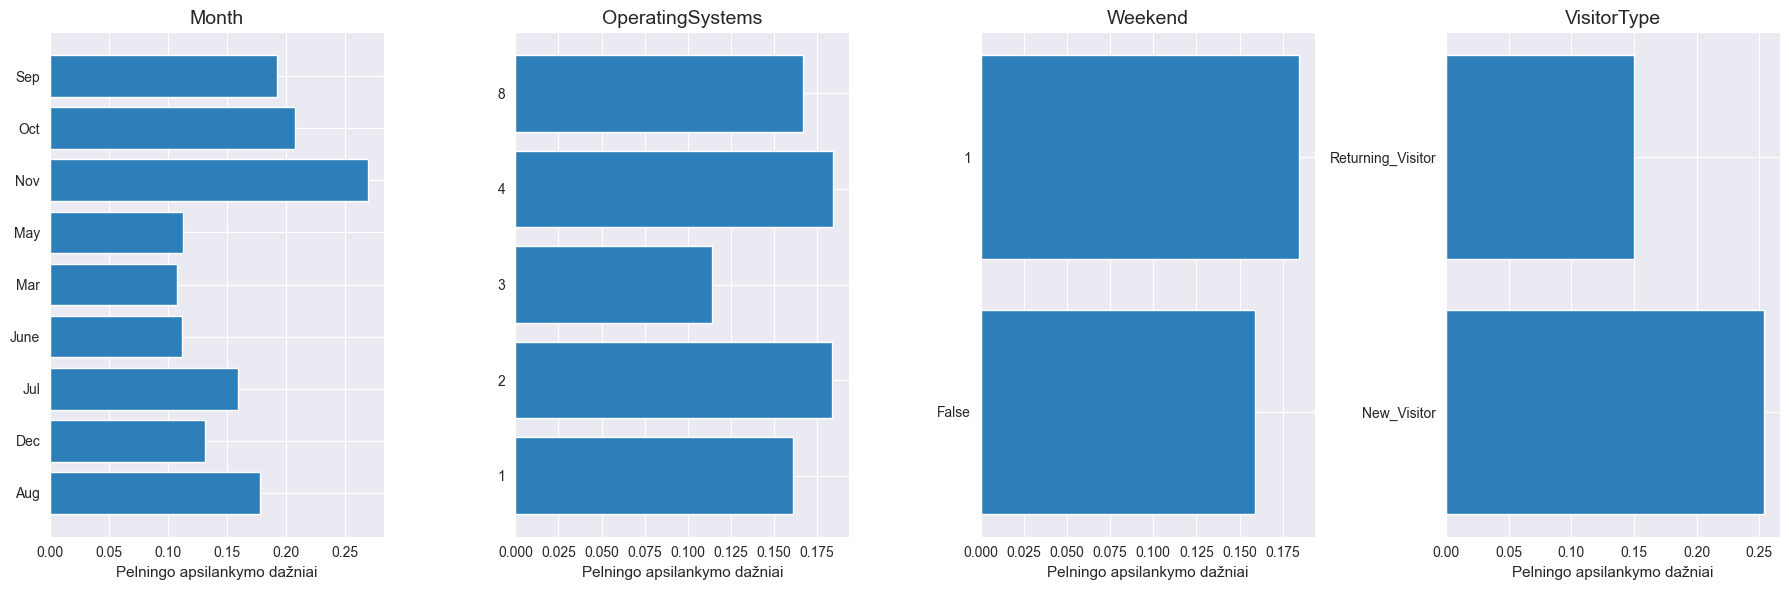

In [124]:
import matplotlib.pyplot as plt

categorical_cols = ["Month", "OperatingSystems", "Weekend", "VisitorType"]

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

df[categorical_cols] = df[categorical_cols].astype("category")

df_long = df[categorical_cols + ["Revenue"]].melt(
    id_vars="Revenue",
    value_vars=categorical_cols,
    var_name="Variable",
    value_name="Category"
)

df_summary = (
    df_long
    .groupby(["Variable", "Category"], observed=True)
    .agg(Rev=("Revenue", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 6))

for ax, var in zip(axes, categorical_cols):
    data = df_summary[df_summary["Variable"] == var].sort_values("Category")
    ax.barh(data["Category"].astype(str), data["Rev"], color="#2C7FB8")
    ax.set_title(var, fontsize=14)
    ax.set_xlabel("Pelningo apsilankymo dažniai", fontsize=11)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

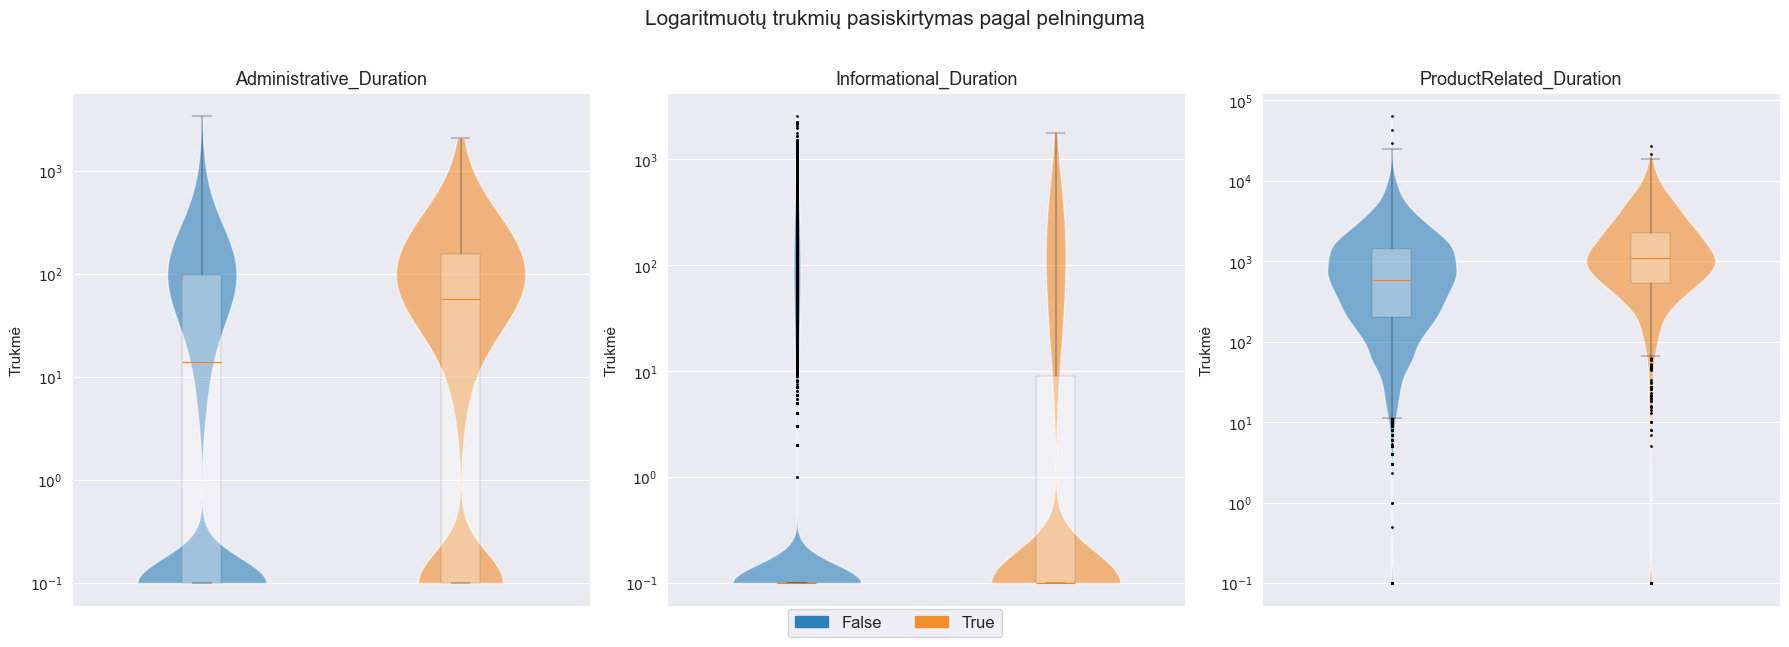

In [125]:
import matplotlib.ticker as ticker
import numpy as np

df_with_revenue = (
    df
    .assign(Revenue=df["Revenue"].astype("category"))
    .drop(columns=["Informational", "ProductRelated", "Administrative"])
)

num_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

df_long = df_with_revenue.melt(
    id_vars="Revenue",
    value_vars=num_cols,
    var_name="variable",
    value_name="value"
)

revenue_vals = [False, True]
colors = {False: "#2C7FB8", True: "#F28E2B"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, num_cols):
    data = df_long[df_long["variable"] == var]

    parts = ax.violinplot(
        [np.log10(data[data["Revenue"] == r]["value"].clip(lower=0.1)) for r in revenue_vals],
        positions=[1, 2],
        showextrema=False
    )
    for pc, r in zip(parts["bodies"], revenue_vals):
        pc.set_facecolor(colors[r])
        pc.set_alpha(0.6)

    for i, r in enumerate(revenue_vals, start=1):
        vals = np.log10(data[data["Revenue"] == r]["value"].clip(lower=0.1))
        ax.boxplot(
            vals,
            positions=[i],
            widths=0.15,
            patch_artist=True,
            boxprops=dict(facecolor="white", alpha=0.3, linewidth=0.3),
            medianprops=dict(linewidth=0.8),
            whiskerprops=dict(linewidth=0.3),
            capprops=dict(linewidth=0.3),
            flierprops=dict(markersize=1)
        )

    ax.set_title(var, fontsize=13)
    ax.set_ylabel("Trukmė", fontsize=11)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"$10^{{{x:.0f}}}$"))

fig.suptitle(
    "Logaritmuotų trukmių pasiskirtymas pagal pelningumą",
    fontsize=15, y=1.02
)

legend_handles = [
    plt.matplotlib.patches.Patch(color=colors[r], label=str(r))
    for r in revenue_vals
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

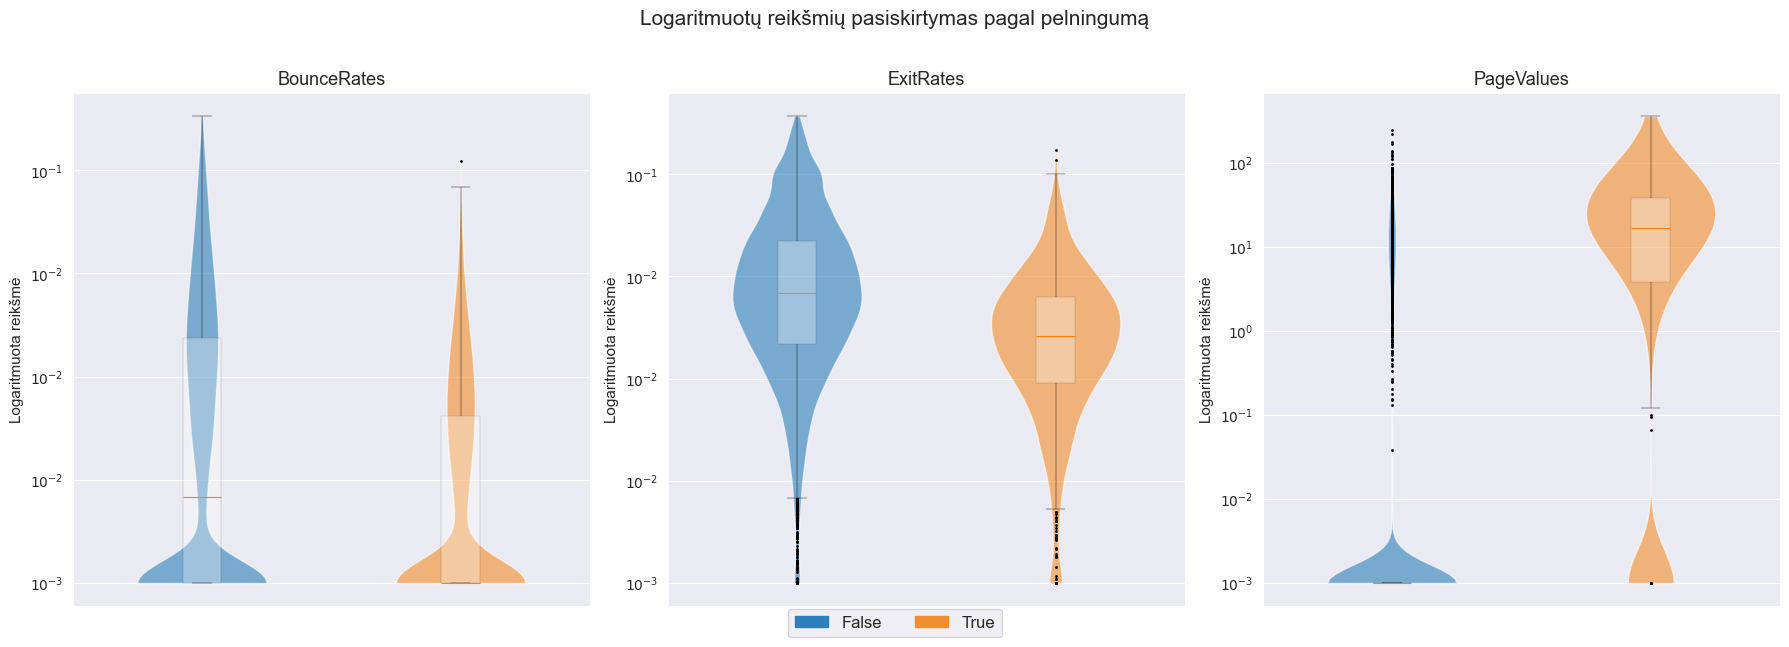

In [126]:
df_with_revenue = (
    df
    .assign(Revenue=df["Revenue"].astype("category"))
    .drop(columns=["Informational", "ProductRelated", "Administrative"])
)

num_cols = ["BounceRates", "ExitRates", "PageValues"]

df_long = df_with_revenue.melt(
    id_vars="Revenue",
    value_vars=num_cols,
    var_name="variable",
    value_name="value"
)

revenue_vals = [False, True]
colors = {False: "#2C7FB8", True: "#F28E2B"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, num_cols):
    data = df_long[df_long["variable"] == var]

    parts = ax.violinplot(
        [np.log10(data[data["Revenue"] == r]["value"].clip(lower=0.001)) for r in revenue_vals],
        positions=[1, 2],
        showextrema=False
    )
    for pc, r in zip(parts["bodies"], revenue_vals):
        pc.set_facecolor(colors[r])
        pc.set_alpha(0.6)

    for i, r in enumerate(revenue_vals, start=1):
        vals = np.log10(data[data["Revenue"] == r]["value"].clip(lower=0.001))
        ax.boxplot(
            vals,
            positions=[i],
            widths=0.15,
            patch_artist=True,
            boxprops=dict(facecolor="white", alpha=0.3, linewidth=0.3),
            medianprops=dict(linewidth=0.8),
            whiskerprops=dict(linewidth=0.3),
            capprops=dict(linewidth=0.3),
            flierprops=dict(markersize=1)
        )

    ax.set_title(var, fontsize=13)
    ax.set_ylabel("Logaritmuota reikšmė", fontsize=11)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"$10^{{{x:.0f}}}$"))

fig.suptitle(
    "Logaritmuotų reikšmių pasiskirtymas pagal pelningumą",
    fontsize=15, y=1.02
)

legend_handles = [
    plt.matplotlib.patches.Patch(color=colors[r], label=str(r))
    for r in revenue_vals
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

# Smote

In [127]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

# Duomenų padalinimas 80/20, stratifikuojant pagal Revenue
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Revenue"]
)

# Revenue konvertavimas į 0/1
train_df = train_df.copy()
test_df  = test_df.copy()
train_df["Revenue"] = train_df["Revenue"].astype(int)
test_df["Revenue"]  = test_df["Revenue"].astype(int)

# SMOTENC – reikia nurodyti kategorinių stulpelių indeksus
X_train = train_df.drop(columns=["Revenue"])
y_train = train_df["Revenue"]

cat_cols   = X_train.select_dtypes(include="category").columns.tolist()
cat_indices = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(categorical_features=cat_indices, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

train_df_smote = pd.DataFrame(X_resampled, columns=X_train.columns)
train_df_smote["Revenue"] = y_resampled

# Sumaišymas (shuffle)
train_df_smote = train_df_smote.sample(frac=1, random_state=42).reset_index(drop=True)

print(train_df_smote["Revenue"].value_counts())

Revenue
1    7265
0    7265
Name: count, dtype: int64


In [128]:
y = train_df_smote["Revenue"].astype(int)
X = train_df_smote.drop(columns=["Revenue"])
X_test_raw = test_df.drop(columns=["Revenue"])
y_test = test_df["Revenue"].astype(int)

# One-hot encoding ABU vienu metu, kad stulpeliai sutaptų
X_full = pd.get_dummies(
    pd.concat([X, X_test_raw], keys=["train", "test"]),
    drop_first=True
).astype(float)

X       = X_full.xs("train")
X_test  = X_full.xs("test")

# Šaliname konstantinius stulpelius
X = X.loc[:, X.std() > 0]
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Interceptas
X      = sm.add_constant(X)
X_test = sm.add_constant(X_test, has_constant="add")

# Modelių apmokymas
logit_results   = sm.Logit(y, X).fit(method="bfgs", maxiter=300, disp=False)
probit_results  = sm.Probit(y, X).fit(method="bfgs", maxiter=300, disp=False)
cloglog_results = sm.GLM(
    y, X,
    family=sm.families.Binomial(link=sm.families.links.cloglog())
).fit(disp=False)

/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessia

/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The cloglog link alias is deprecated. Use CLogLog instead. The cloglog link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:989: RuntimeWarning: overflow encountered in exp
  return 1 - np.exp(-np.exp(z))


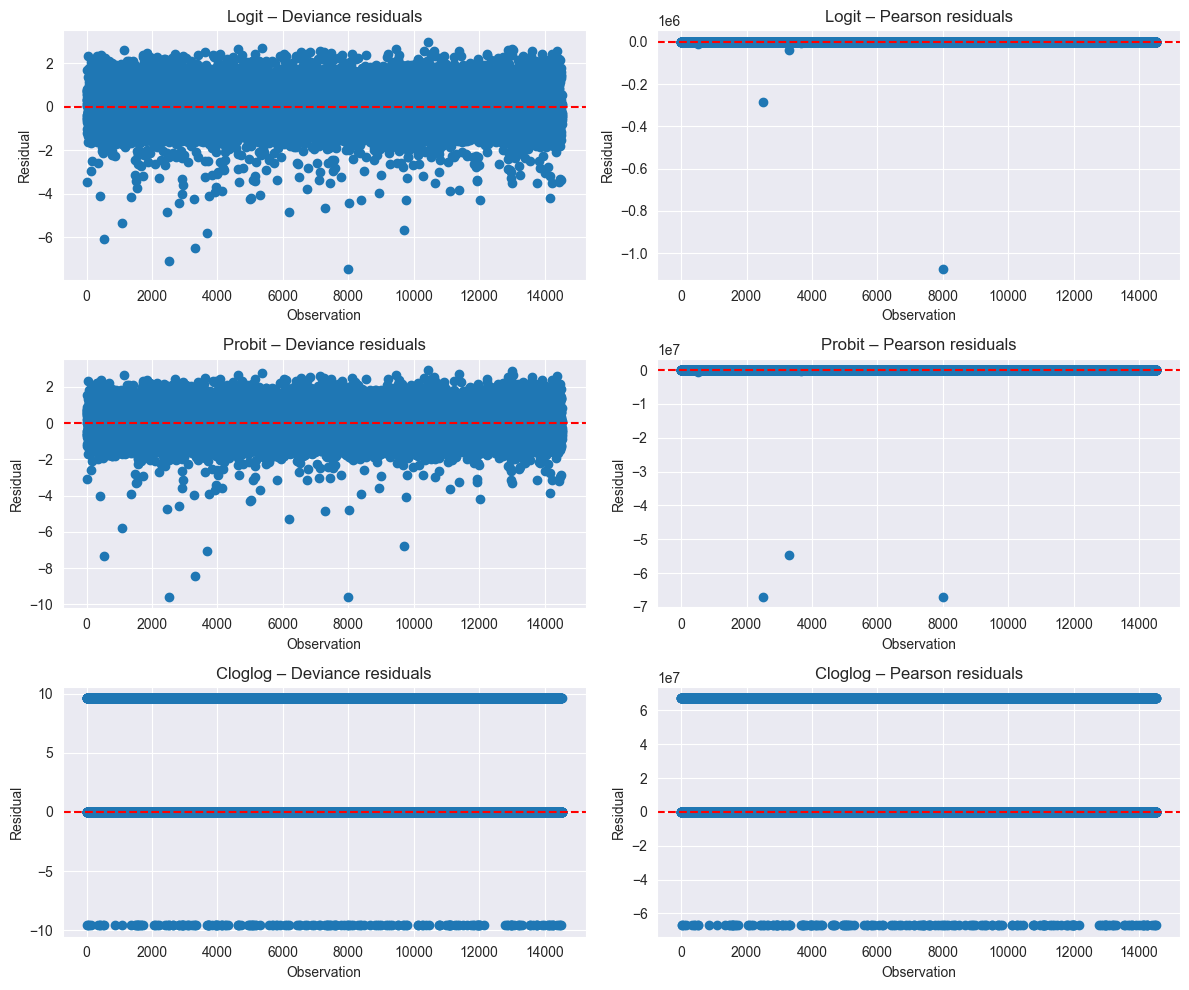

In [129]:
# Logit per GLM
logit_glm = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# Probit per GLM
probit_glm = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.probit())).fit()
# Cloglog
cloglog_glm = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.cloglog())).fit()


models = {
    "Logit": logit_glm,
    "Probit": probit_glm,
    "Cloglog": cloglog_glm
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    dev_resid = model.resid_deviance
    pearson_resid = model.resid_pearson

    axes[2*i].scatter(range(len(y)), dev_resid)
    axes[2*i].axhline(0, color='red', linestyle='--')
    axes[2*i].set_title(f"{name} – Deviance residuals")
    axes[2*i].set_xlabel("Observation")
    axes[2*i].set_ylabel("Residual")

    axes[2*i+1].scatter(range(len(y)), pearson_resid)
    axes[2*i+1].axhline(0, color='red', linestyle='--')
    axes[2*i+1].set_title(f"{name} – Pearson residuals")
    axes[2*i+1].set_xlabel("Observation")
    axes[2*i+1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [130]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Tarkime X_train turi tavo kintamuosius
columns_of_interest = ['Administrative','Administrative_Duration', 'Informational',
                       'Informational_Duration','ProductRelated','ProductRelated_Duration',
                       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

# Pridedam konstantą
X = sm.add_constant(X_train[columns_of_interest])

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

X.drop(columns = ['ProductRelated'], inplace = True)
X_test.drop(columns = ['ProductRelated'], inplace = True)

                    feature       VIF
0                     const  4.917878
1            Administrative  1.983001
2   Administrative_Duration  1.725998
3             Informational  1.925147
4    Informational_Duration  1.747490
5            ProductRelated  4.392453
6   ProductRelated_Duration  4.407282
7               BounceRates  2.468035
8                 ExitRates  2.757706
9                PageValues  1.042369
10               SpecialDay  1.044874


In [131]:
def plot_cm(y_true, y_pred, title="", show_values=True, ax=None):
    """
    Piešia confusion matrix.

    y_true : tikros klasės
    y_pred : prognozuotos klasės
    title  : grafiko pavadinimas
    show_values : ar rodyti skaičius matricoje
    ax     : matplotlib axes objektas
    """
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots()

    sns.heatmap(cm, annot=show_values, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/edwin2/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessia

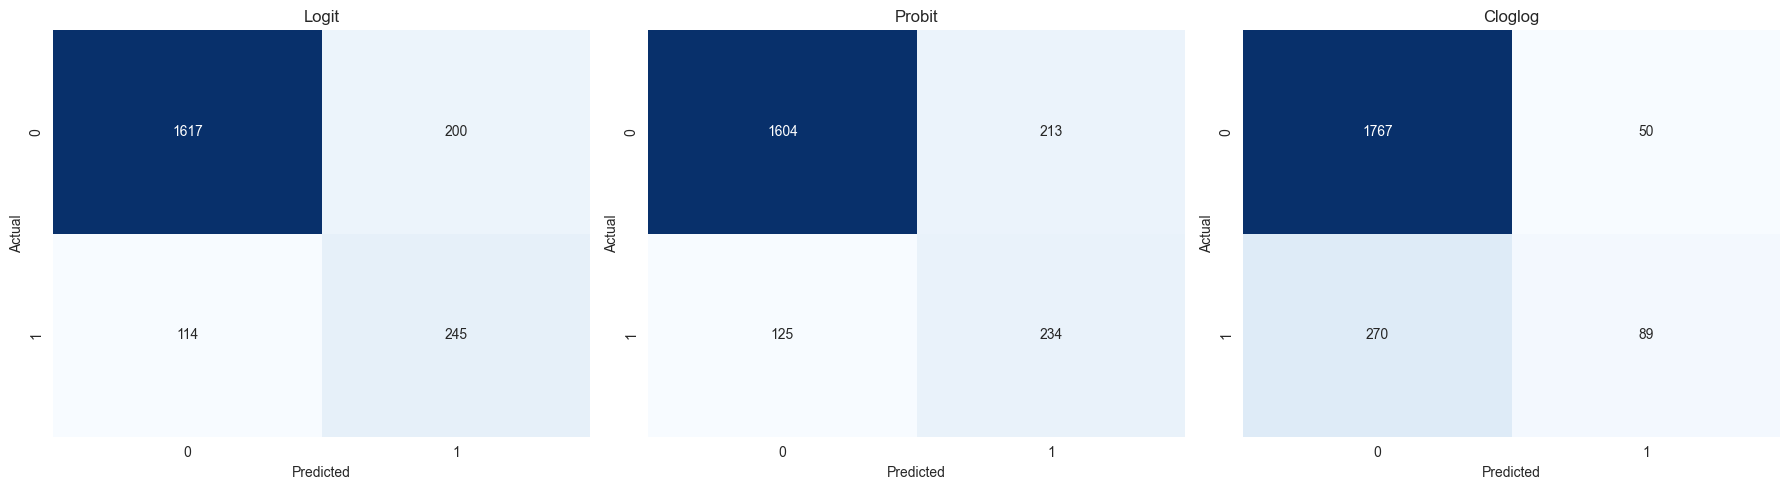

In [132]:
y = train_df_smote["Revenue"].astype(int)
X = train_df_smote.drop(columns=["Revenue"])
X_test_raw = test_df.drop(columns=["Revenue"])
y_test = test_df["Revenue"].astype(int)

# One-hot encoding ABU vienu metu, kad stulpeliai sutaptų
X_full = pd.get_dummies(
    pd.concat([X, X_test_raw], keys=["train", "test"]),
    drop_first=True
).astype(float)

X       = X_full.xs("train")
X_test  = X_full.xs("test")

# Šaliname konstantinius stulpelius
X = X.loc[:, X.std() > 0]
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Interceptas
X      = sm.add_constant(X)
X_test = sm.add_constant(X_test, has_constant="add")

# Modelių apmokymas
logit_results   = sm.Logit(y, X).fit(method="bfgs", maxiter=300, disp=False)
probit_results  = sm.Probit(y, X).fit(method="bfgs", maxiter=300, disp=False)
cloglog_results = sm.GLM(
    y, X,
    family=sm.families.Binomial(link=sm.families.links.cloglog())
).fit(disp=False)

# Prognozės
probs1 = logit_results.predict(X_test)
probs2 = probit_results.predict(X_test)
probs3 = cloglog_results.predict(X_test)

pred1 = (probs1 > 0.5).astype(int)
pred2 = (probs2 > 0.5).astype(int)
pred3 = (probs3 > 0.5).astype(int)

# Klasifikavimo matricos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(y_test, pred1, "Logit",   True,  axes[0])
plot_cm(y_test, pred2, "Probit",  True, axes[1])
plot_cm(y_test, pred3, "Cloglog", True, axes[2])

plt.tight_layout()
plt.show()

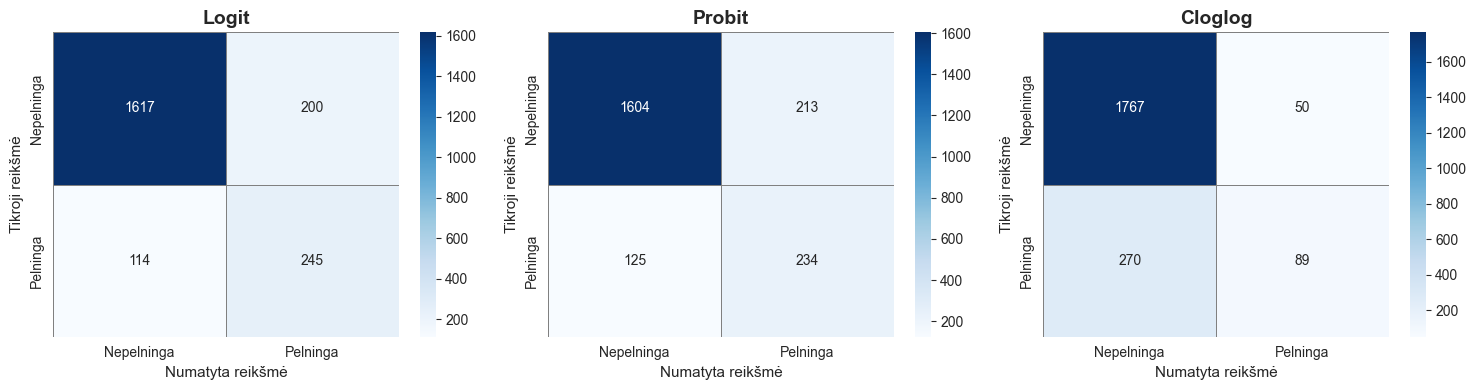

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    (pred1, "Logit"),
    (pred2, "Probit"),
    (pred3, "Cloglog")
]

for ax, (pred, title) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Nepelninga", "Pelninga"],
                yticklabels=["Nepelninga", "Pelninga"],
                linewidths=0.5, linecolor="gray")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Numatyta reikšmė", fontsize=11)
    ax.set_ylabel("Tikroji reikšmė", fontsize=11)

plt.tight_layout()
plt.show()

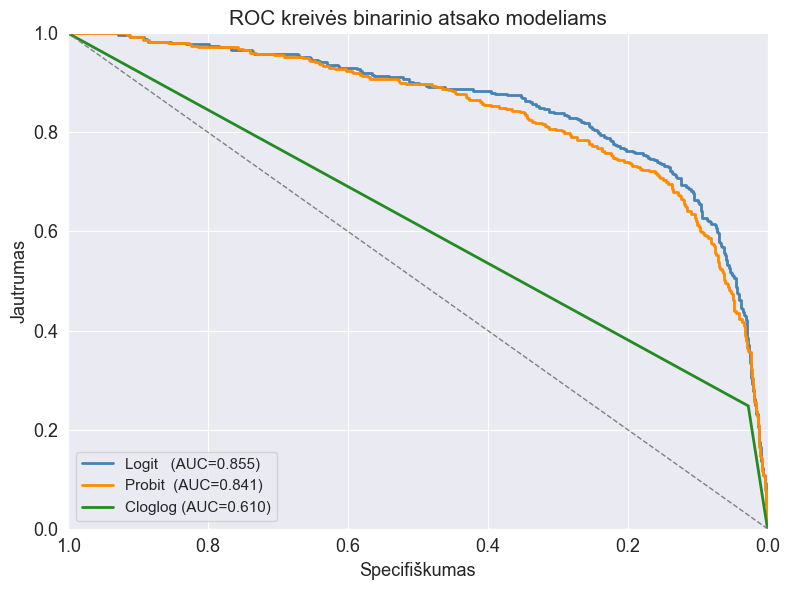

In [134]:
from sklearn.metrics import roc_curve, auc

# ROC kreivių skaičiavimas
fpr1, tpr1, _ = roc_curve(y_test, probs1)
fpr2, tpr2, _ = roc_curve(y_test, probs2)
fpr3, tpr3, _ = roc_curve(y_test, probs3)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)

# Grafikai
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr1, tpr1, color="steelblue",   lw=2, label=f"Logit   (AUC={auc1:.3f})")
ax.plot(fpr2, tpr2, color="darkorange",  lw=2, label=f"Probit  (AUC={auc2:.3f})")
ax.plot(fpr3, tpr3, color="forestgreen", lw=2, label=f"Cloglog (AUC={auc3:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.invert_xaxis()  # specifiškumas mažėja iš kairės į dešinę (kaip R)
ax.set_title("ROC kreivės binarinio atsako modeliams", fontsize=15)
ax.set_xlabel("Specifiškumas", fontsize=13)
ax.set_ylabel("Jautrumas", fontsize=13)
ax.tick_params(labelsize=13)
ax.legend(loc="lower left", fontsize=11)

plt.tight_layout()
plt.show()

In [135]:
def add_features(df):
    df = df.copy()
    df["PageValues_x_Pages"]      = (df["Administrative"] + df["Informational"]) * df["PageValues"]
    df["Average_Administrative"]  = df["Administrative_Duration"] / df["Administrative"]
    df["Average_Informational"]   = df["Informational_Duration"]  / df["Informational"]
    df[["Average_Administrative", "Average_Informational"]] = (
        df[["Average_Administrative", "Average_Informational"]].fillna(0)
    )
    return df

train_df = add_features(train_df_smote)
test_df  = add_features(test_df)

# Slenkstis


In [136]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score

# Prognozės
probs1 = logit_results.predict(X_test)

# ROC kreivė
fpr, tpr, thresholds = roc_curve(y_test, probs1)

# Youden indeksas: max(sensitivity + specificity - 1)
youden_idx       = np.argmax(tpr - fpr)
best_threshold   = thresholds[youden_idx]
best_sensitivity = tpr[youden_idx]
best_specificity = 1 - fpr[youden_idx]

# Prognozės su optimalia riba
pred_youden = (probs1 >= best_threshold).astype(int)

# Metrikos
ppv = precision_score(y_test, pred_youden, zero_division=0)
sen = recall_score(y_test, pred_youden, zero_division=0)
f1  = 2 * (ppv * sen) / (ppv + sen) if (ppv + sen) > 0 else 0
acc = accuracy_score(y_test, pred_youden)

results = pd.DataFrame([{
    "Riba"              : round(best_threshold,   4),
    "Jautrumas"         : round(best_sensitivity, 4),
    "Preciziškumas"     : round(ppv,              4),
    "F1"                : round(f1,               4),
    "Tikslumas"         : round(acc,              4),
    "Joudeno indeksas"  : round(best_sensitivity + best_specificity - 1, 4),
}])

results

,Riba,Jautrumas,Preciziškumas,F1,Tikslumas,Joudeno indeksas
0,0.4293,0.7326,0.5048,0.5977,0.8373,0.5906


# Pažingsninė regresija

In [137]:
def forward_selection(X_train, y_train):
    selected = []
    remaining = list(X_train.columns)
    current_aic = sm.Logit(y_train, sm.add_constant(pd.DataFrame(index=X_train.index))).fit(disp=0).aic

    while remaining:
        aic_candidates = []
        for candidate in remaining:
            cols = selected + [candidate]
            X_temp = sm.add_constant(X_train[cols])
            model = sm.Logit(y_train, X_temp).fit(disp=0)
            aic_candidates.append((model.aic, candidate, model))

        aic_candidates.sort()
        best_aic, best_candidate, best_model = aic_candidates[0]

        if best_aic < current_aic:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
            current_aic = best_aic
            print(f"Pridėtas: {best_candidate} | AIC: {best_aic:.4f}")
        else:
            break

    print(f"\nAtrinkti kintamieji: {selected}")
    return best_model

X_train = X.astype(float)
X_test = X_test.astype(float)
y_train = y.astype(float)
y_test = y_test.astype(float)

final_model = forward_selection(X_train, y_train)
print(final_model.summary())

Pridėtas: PageValues | AIC: 13798.0427
Pridėtas: Month_Nov | AIC: 12293.0980
Pridėtas: OperatingSystems_2 | AIC: 11897.1329
Pridėtas: ExitRates | AIC: 11613.4164
Pridėtas: Browser_2 | AIC: 11481.0085
Pridėtas: OperatingSystems_3 | AIC: 11381.2132
Pridėtas: Weekend_True | AIC: 11294.4063
Pridėtas: OperatingSystems_4 | AIC: 11252.9666
Pridėtas: Region_9 | AIC: 11221.2272
Pridėtas: Region_6 | AIC: 11195.7415
Pridėtas: Browser_6 | AIC: 11175.1928
Pridėtas: SpecialDay | AIC: 11157.6790
Pridėtas: Region_2 | AIC: 11142.9134
Pridėtas: Region_4 | AIC: 11125.9293
Pridėtas: Region_7 | AIC: 11107.9025
Pridėtas: Region_5 | AIC: 11091.5193
Pridėtas: Region_8 | AIC: 11077.8135
Pridėtas: VisitorType_Returning_Visitor | AIC: 11065.7936
Pridėtas: Browser_5 | AIC: 11056.4320
Pridėtas: Browser_4 | AIC: 11048.1416
Pridėtas: Month_Dec | AIC: 11039.8320
Pridėtas: Region_3 | AIC: 11032.7063
Pridėtas: Month_Mar | AIC: 11026.7387
Pridėtas: Browser_10 | AIC: 11022.3099
Pridėtas: OperatingSystems_8 | AIC: 11018.7